<a href="https://colab.research.google.com/github/beena24/Research_works/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
#from sklearn.datasets import load_iris

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_csv('/content/drive/MyDrive/final_class.csv')
data.head()

,image_name,ax,ay,az,aa,ab,ac,bx,by,bz,...,ea,eb,ec,fx,fy,fz,fa,fb,fc,class_label
0,1,10.357803,0.947747,0.377892,0.271344,0.073628,527.604354,12.355004,0.923771,0.344400,...,0.271344,0.073628,527.604354,10.638161,0.937800,0.361793,0.265446,0.070462,627.031350,0
1,2,9.943303,0.972922,0.158823,0.013871,0.000192,228.172224,10.470005,0.971091,0.129137,...,0.013871,0.000192,228.172224,8.907396,0.978147,0.149007,0.014363,0.000206,185.602432,0
2,3,13.804682,0.933498,0.149651,0.054728,0.002995,455.342305,13.049888,0.942372,0.152733,...,0.054728,0.002995,455.342305,10.934059,0.958412,0.171546,0.063858,0.004078,290.135010,0
3,4,11.348370,0.945048,0.161277,0.060145,0.003617,312.986486,10.720394,0.951502,0.165493,...,0.060145,0.003617,312.986486,9.057216,0.962559,0.190166,0.072873,0.005310,217.689189,0
4,5,12.256108,0.949087,0.238345,0.157359,0.024762,434.594887,11.254383,0.957831,0.246050,...,0.157359,0.024762,434.594887,9.513388,0.968220,0.265587,0.169954,0.028884,271.700871,0


In [ ]:
y=data.class_label
x=data.drop('class_label',axis=1)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)
x_train.head()

,image_name,ax,ay,az,aa,ab,ac,bx,by,bz,...,ez,ea,eb,ec,fx,fy,fz,fa,fb,fc
3759,3760,9.358596,0.906239,0.181196,0.023632,0.000558,318.670404,9.370435,0.905716,0.176975,...,0.181196,0.023632,0.000558,318.670404,8.314007,0.920096,0.202352,0.026357,0.000695,268.122930
4577,4578,10.264849,0.919973,0.119971,0.013608,0.000185,335.553415,9.782859,0.922503,0.126913,...,0.119971,0.013608,0.000185,335.553415,8.352102,0.937489,0.152174,0.015162,0.000230,260.399536
5274,5275,4.401066,0.980920,0.292420,0.025252,0.000638,83.979867,4.416949,0.981533,0.282213,...,0.292420,0.025252,0.000638,83.979867,3.844114,0.984906,0.306076,0.025603,0.000656,66.745020
5402,5403,3.979764,0.991100,0.277090,0.021642,0.000468,48.033222,3.973280,0.991513,0.272737,...,0.277090,0.021642,0.000468,48.033222,3.724656,0.992729,0.282825,0.021943,0.000481,39.263712
6851,222,8.791542,0.970299,0.251646,0.126816,0.016082,254.641596,8.007202,0.975502,0.263443,...,0.251646,0.126816,0.016082,254.641596,6.423947,0.983233,0.292434,0.139149,0.019363,145.827760


In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


In [ ]:
bootstrap=True

In [ ]:
from numpy import sqrt

In [ ]:
import graphviz
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.model_selection import GridSearchCV




In [ ]:
classifier=RandomForestClassifier(random_state=90,oob_score=True)
classifier.fit(x,y)
classifier.oob_score_


0.9564890282131662

In [ ]:
params={'max_depth':[15,20,25],'max_features':['auto','sqrt'],'min_samples_split':[10,10,25],'min_samples_leaf':[5,10],'n_estimators':[25,30],}
rf_grid=GridSearchCV(estimator=classifier,param_grid=params,cv=5,scoring="accuracy")





In [ ]:
rf_grid.fit(x,y)
rf_grid.best_score_


0.8430094043887149

In [ ]:
best_model=rf_grid.best_estimator_

print(best_model)

RandomForestClassifier(max_depth=20, min_samples_leaf=10, min_samples_split=10,
                       n_estimators=25, oob_score=True, random_state=90)


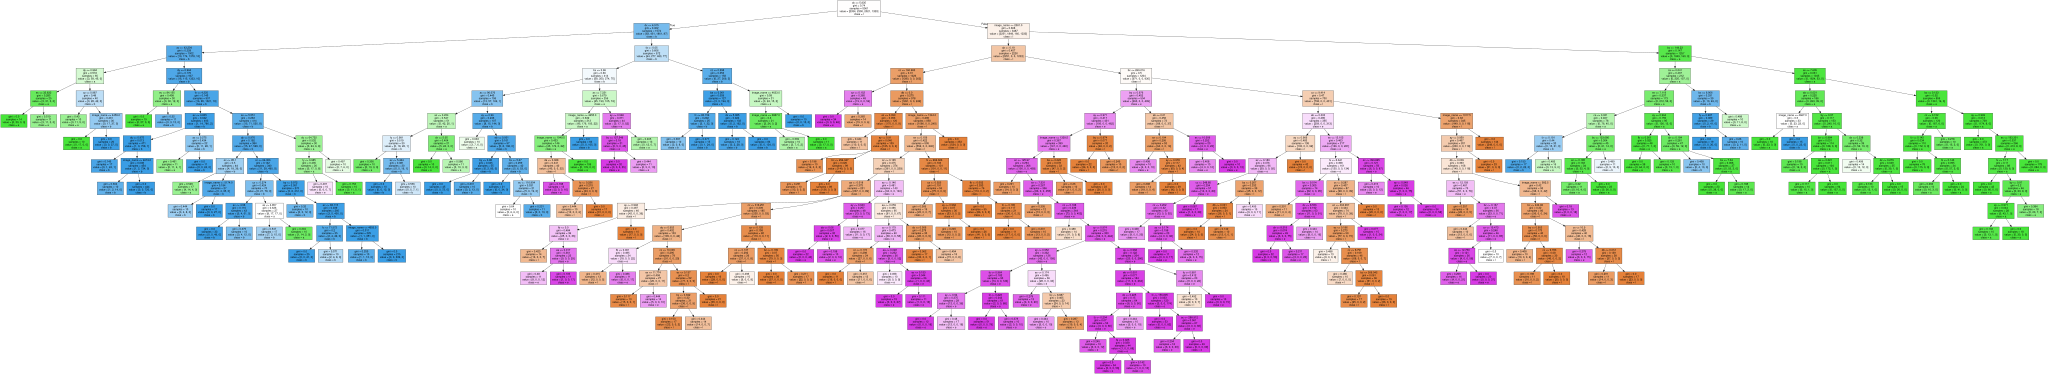

In [ ]:
dot_data = tree.export_graphviz(best_model.estimators_[0],out_file=None,feature_names=x.columns,class_names="label",filled=True)
graph = graphviz.Source(dot_data,format="png")
graph

GRID-CV

In [ ]:
#Random Forest
from sklearn.model_selection import GridSearchCV
# Define the hyperparameter configuration space
rf_params = {
    'n_estimators': [90,100,150,130],
    'max_features': ['sqrt','auto','log2'],
    'max_depth': range(2,20),
    'min_samples_leaf': [1,2,4,8,10],
    "bootstrap":[True],
    "criterion":['gini','entropy']
}
clf = RandomForestClassifier(random_state=0)
grid = GridSearchCV(clf, rf_params, cv=3, scoring='accuracy')
grid.fit(x, y)
print(grid.best_params_)
print("Accuracy:"+ str(grid.best_score_))